# Best practice: transparently cache files on the local filesystem

Earth Data Hub offers an innovative and super-efficient way to access data.

Here we present how to easily convert your code to use transparent caching of the data chunks on the local file system. By caching the data locally you have two benefits:
* accessing the same data doesn't download data from the EDH again, this is especially useful on slow connections
* even if you have a fast connection, accessing the same data doesn't consume EDH credits

You can setup caching in a variety of way, what we present here is the simplest setup where you only need to change the way you open the data, all processing code need no change between online access and locally cached access.

## Setup the environment

**If you haven't done it already, follow the [Getting started notebook](./00-getting-started.ipynb) to setup your environment and DestinE credentials.**

## Download 30 years of an ERA5 variable on a small area

In the following we reproduce the use case in the [ERA5 on a small area notebook](./10-use-case-era5-small-area.ipynb) adding the code to cache data on the local file system using the `simplecache` directive of _fsspec_. The changes from the case without cache are _described in italic_.

Our use case is to compute various climatological averages of one ERA5 variable over a long period of time, e.g. the surface temperature over 30 years. Note that we will be using the ERA5 single levels dataset that has more than 100 variable and every variable is almost 3TB in size. 

The best practice for downloading data form the Earth Data Hub comprise the following steps:
1. open the dataset using the code snippet found on the [ERA5 dataset page](https://earthdatahub.destine.eu/collections/era5/datasets/reanalysis-era5-single-levels). _In oder to enable and configure transparent caching you need to change the code snippet._
2. select the variable
3. select the area of interest (optionally aligning it on chunk boundaries)
4. select the time interval of interest
5. download the data to memory (with `.persist()` or `.compute()`)
6. compute the result in memory

### Open the dataset

The following assumes you set up the EDH Personal Access Token in your _netrc_ file.

_All caching configuration is done in the call to `xr.open_dataset`. To enable the [simple fsspec caching](https://filesystem-spec.readthedocs.io/en/latest/features.html#caching-files-locally) we add the `simplecache::` directive before the Zarr store URL. Then we need to add also the experimental `asyncwrapper::` directive because the Zarr engine expects an asynchronous fsspec store, and the `simplecache` one is not fully async._

_After activating the local cache we need to adjust the value of the storage_option keyword to specify the configuration of the HTTP access and of the cache. Note that simplecache doesn't expire files automatically so the cache folder needs to be clean by hand. We suggest to use different folders for different datasets to easy cache maintenance. See the fsspec documentation for [all the options supported by simplecache](https://filesystem-spec.readthedocs.io/en/latest/api.html#fsspec.implementations.cached.SimpleCacheFileSystem)._

In [1]:
import xarray as xr

era5_single_levels_dataset = xr.open_dataset(
    "asyncwrapper::simplecache::https://data.earthdatahub.destine.eu/era5/reanalysis-era5-single-levels-v0.zarr",
    storage_options={
        "https": {"client_kwargs": {"trust_env": True}},
        "simplecache": {"cache_storage": "/tmp/edh_cache/era5-single-levels"},
    },
    chunks={},
    engine="zarr",
).drop_vars(["surface", "number"])
era5_single_levels_dataset

<xarray.Dataset> Size: 405TB
Dimensions:     (valid_time: 756768, latitude: 721, longitude: 1440)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 6MB 1940-01-01 ... 2026-04-30T23:...
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
Data variables: (12/129)
    alnid       (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
    alnip       (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
    aluvd       (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
    aluvp       (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
    anor        (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
    asn         (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
    ...          ...
    viiwn       (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
    vilwd       (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
    vilwe       (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
    vilwn       (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
    z           (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
    zust        (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2025-12-04T16:25 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

_From now on there is no change to the code. The first time that the code is run the data is downloaded to the local cache and then used every time the notebook is run. Note that the default expiry time is one week, after that the data is downloaded again._

### Select and prepare the variable

Note that all operation are lazy, that is are not applied to the whole 3TB of data, but are just recorded for later use. Download and computations are only done when requested.

In [2]:
t2m_world = era5_single_levels_dataset.t2m
t2m_world

<xarray.DataArray 't2m' (valid_time: 756768, latitude: 721, longitude: 1440)> Size: 3TB
dask.array<open_dataset-t2m, shape=(756768, 721, 1440), dtype=float32, chunksize=(4320, 64, 64), chunktype=numpy.ndarray>
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 6MB 1940-01-01 ... 2026-04-30T23:...
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
Attributes: (12/31)
    GRIB_NV:                                  0
    GRIB_Nx:                                  1440
    GRIB_Ny:                                  721
    GRIB_cfName:                              unknown
    GRIB_cfVarName:                           t2m
    GRIB_dataType:                            an
    ...                                       ...
    GRIB_typeOfLevel:                         surface
    GRIB_units:                               K
    GRIB_uvRelativeToGrid:                    0
    long_name:                                2 metre temperature
    standard_name:                            unknown
    units:                                    K

### Select the area of interest

For example we are interested in the area of the Alps.

This a very convenient example as:
* it is a large enough area to be more interesting than a time-series of a single point,
* it is small enough to fit a single Zarr chunk, so the notebook can be run even with a slow internet connection,
* when plotted it is easy to identify even without adding coastlines and country borders that will make the notebook more complex.

In [3]:
aoi_selection = {
    "latitude": slice(49, 43),  # NOTE: ERA5 has a descending latitude coordinate
    "longitude": slice(5, 15),
}
t2m_aoi = t2m_world.sel(aoi_selection)
t2m_aoi

<xarray.DataArray 't2m' (valid_time: 756768, latitude: 25, longitude: 41)> Size: 3GB
dask.array<getitem, shape=(756768, 25, 41), dtype=float32, chunksize=(4320, 25, 41), chunktype=numpy.ndarray>
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 6MB 1940-01-01 ... 2026-04-30T23:...
  * latitude    (latitude) float64 200B 49.0 48.75 48.5 ... 43.5 43.25 43.0
  * longitude   (longitude) float64 328B 5.0 5.25 5.5 5.75 ... 14.5 14.75 15.0
Attributes: (12/31)
    GRIB_NV:                                  0
    GRIB_Nx:                                  1440
    GRIB_Ny:                                  721
    GRIB_cfName:                              unknown
    GRIB_cfVarName:                           t2m
    GRIB_dataType:                            an
    ...                                       ...
    GRIB_typeOfLevel:                         surface
    GRIB_units:                               K
    GRIB_uvRelativeToGrid:                    0
    long_name:                                2 metre temperature
    standard_name:                            unknown
    units:                                    K

Note that the data size is now much smaller, we went from 3TB for global data to 3GB of our small area of interest.

We plot the map of the temperature at one time to double check that the selection is correct:

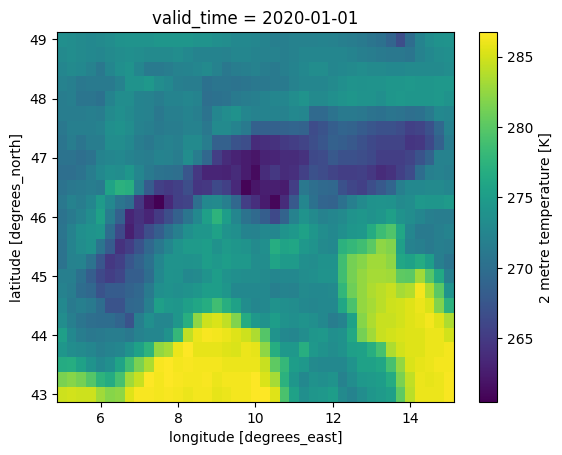

In [4]:
t2m_aoi.sel(valid_time="2020-01-01T00:00:00").plot()

### Optional: allign the area of interest on chunk boundaries

This a pro move and you can skip it.

When accessing the data in Zarr you always download whole chunks, even if you are only interested in part of them. In the case of ERA5 single level the spatial chunks are `(64, 64)` in size and even if you can read above that your DataArray in only 2GB of data you are most probably downloading more data and then throwing a part of it away.

You can use the following (not very nice) code to grow your area of interest to the boundaries of the Zarr chunks, so you use all the data you download. Note that now you also have the size of the data that would be downloaded is it was not compressed (the data is in fact compressed so actual download is smaller).

In [5]:
def align_indexer(step, indexer):
    if not isinstance(indexer, slice):
        return indexer
    assert indexer.step is None
    start = indexer.start // step * step if indexer.start else indexer.start
    stop = ((indexer.stop - 1) // step + 1) * step if indexer.stop else indexer.stop
    return slice(start, stop)


query_results = xr.core.indexing.map_index_queries(
    t2m_world, indexers=aoi_selection, method=None, tolerance=None
)
print(query_results.dim_indexers)

aoi_iselection = {
    dim: align_indexer(64, query_results.dim_indexers[dim])
    for dim in query_results.dim_indexers
}
print(aoi_iselection)

t2m_aoi = t2m_world.isel(aoi_iselection)
t2m_aoi

{'latitude': slice(164, 189, None), 'longitude': slice(20, 61, None)}
{'latitude': slice(128, 192, None), 'longitude': slice(0, 64, None)}


<xarray.DataArray 't2m' (valid_time: 756768, latitude: 64, longitude: 64)> Size: 12GB
dask.array<getitem, shape=(756768, 64, 64), dtype=float32, chunksize=(4320, 64, 64), chunktype=numpy.ndarray>
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 6MB 1940-01-01 ... 2026-04-30T23:...
  * latitude    (latitude) float64 512B 58.0 57.75 57.5 ... 42.75 42.5 42.25
  * longitude   (longitude) float64 512B 0.0 0.25 0.5 0.75 ... 15.25 15.5 15.75
Attributes: (12/31)
    GRIB_NV:                                  0
    GRIB_Nx:                                  1440
    GRIB_Ny:                                  721
    GRIB_cfName:                              unknown
    GRIB_cfVarName:                           t2m
    GRIB_dataType:                            an
    ...                                       ...
    GRIB_typeOfLevel:                         surface
    GRIB_units:                               K
    GRIB_uvRelativeToGrid:                    0
    long_name:                                2 metre temperature
    standard_name:                            unknown
    units:                                    K

So, the full time-series for a whole chunk is really 11.5GB, not 2GB.

Let's have a look at the area of the whole chunk.

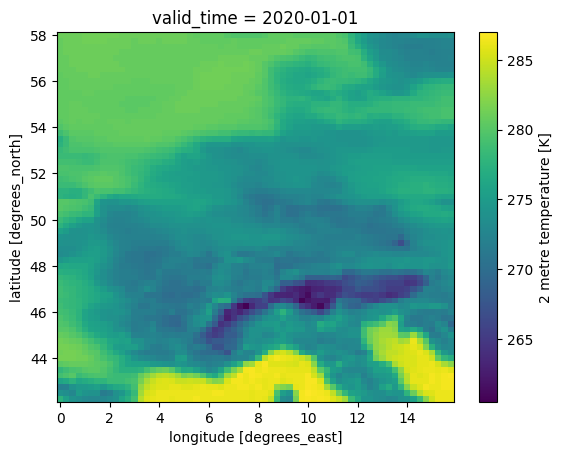

In [6]:
t2m_aoi.sel(valid_time="2020-01-01T00:00:00").plot()

Great! A single 64x64 chunk gets a big part of central Europe.

### Select the time interval of interest

We take one of the typical 30 year periods to compute climatologies and finally we have a definition of the data we want to download.

In [7]:
t2m_aoi_toi = t2m_aoi.sel(valid_time=slice("1981", "2010"))
t2m_aoi_toi

<xarray.DataArray 't2m' (valid_time: 262968, latitude: 64, longitude: 64)> Size: 4GB
dask.array<getitem, shape=(262968, 64, 64), dtype=float32, chunksize=(4320, 64, 64), chunktype=numpy.ndarray>
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 2MB 1981-01-01 ... 2010-12-31T23:...
  * latitude    (latitude) float64 512B 58.0 57.75 57.5 ... 42.75 42.5 42.25
  * longitude   (longitude) float64 512B 0.0 0.25 0.5 0.75 ... 15.25 15.5 15.75
Attributes: (12/31)
    GRIB_NV:                                  0
    GRIB_Nx:                                  1440
    GRIB_Ny:                                  721
    GRIB_cfName:                              unknown
    GRIB_cfVarName:                           t2m
    GRIB_dataType:                            an
    ...                                       ...
    GRIB_typeOfLevel:                         surface
    GRIB_units:                               K
    GRIB_uvRelativeToGrid:                    0
    long_name:                                2 metre temperature
    standard_name:                            unknown
    units:                                    K

From the representation above we learn a few things:
1. the uncompressed data to be downloaded, e.g. 4GB (compression depends on the dataset and the variable)
2. the number of chunks to be downloaded, e.g. 62

### Download the data to memory

Finally we are ready to download only the data that we are interested in, in memory.

The best practice is to call the `.compute()` method load the data into a numpy array in memory.

**_The first time you perform this operation, it is potentially slow. It may takes up to 20 minutes on a 8 Mbps connection. Thanks to local caching accessing the same data again it is much faster and doesn't consume any EDH credit._**

It depends on the download speed of your internet connection and on the load on the Earth Data Hub. The closer you are to the data the faster it is, and this is one of the reason the EDH is best suited to be used from within the DestinE platform.

In [8]:
%%time

t2m_aoi_toi_data = t2m_aoi_toi.compute()

CPU times: user 10.6 s, sys: 11.3 s, total: 21.9 s
Wall time: 24.2 s


### Perform any computation

#### Prepare the raw data 

In [9]:
t2m_aoi_toi_data_C = t2m_aoi_toi_data - 273.15
t2m_aoi_toi_data_C.attrs["units"] = "°C"
t2m_aoi_toi_data_C.attrs["long_name"] = "surface temperature"
t2m_aoi_toi_data_C

<xarray.DataArray 't2m' (valid_time: 262968, latitude: 64, longitude: 64)> Size: 4GB
array([[[ 2.600006 ,  2.600006 ,  2.350006 , ...,  1.6000061,
          1.6000061,  1.8500061],
        [ 2.350006 ,  2.350006 ,  2.100006 , ...,  1.1000061,
          1.3500061,  1.6000061],
        [ 2.850006 ,  2.850006 ,  2.850006 , ...,  1.1000061,
          1.3500061,  1.6000061],
        ...,
        [-6.149994 , -7.149994 , -5.899994 , ..., 10.350006 ,
         10.350006 , 10.850006 ],
        [-2.649994 , -5.649994 , -5.649994 , ...,  9.850006 ,
         10.100006 , 10.350006 ],
        [-1.3999939, -1.1499939, -1.1499939, ...,  9.850006 ,
         10.100006 , 10.100006 ]],

       [[ 3.350006 ,  3.350006 ,  3.100006 , ...,  1.8500061,
          1.8500061,  2.100006 ],
        [ 2.850006 ,  2.850006 ,  2.850006 , ...,  1.1000061,
          1.3500061,  1.6000061],
        [ 3.100006 ,  3.100006 ,  3.100006 , ...,  1.1000061,
          1.3500061,  1.6000061],
...
        [-2.899994 , -3.149994 , -4.149994 , ..., 10.600006 ,
         10.600006 , 10.350006 ],
        [-2.149994 , -1.8999939, -2.149994 , ..., 10.850006 ,
         10.600006 , 10.600006 ],
        [ 1.6000061,  1.3500061,  0.8500061, ..., 10.850006 ,
         11.100006 , 11.100006 ]],

       [[ 6.100006 ,  6.100006 ,  6.100006 , ...,  2.100006 ,
          2.100006 ,  2.100006 ],
        [ 6.350006 ,  6.350006 ,  6.350006 , ...,  1.8500061,
          2.100006 ,  2.100006 ],
        [ 6.600006 ,  6.600006 ,  6.600006 , ...,  1.6000061,
          1.8500061,  1.8500061],
        ...,
        [-2.649994 , -3.149994 , -4.149994 , ..., 10.600006 ,
         10.600006 , 10.350006 ],
        [-2.149994 , -2.149994 , -2.649994 , ..., 10.850006 ,
         10.600006 , 10.600006 ],
        [ 1.6000061,  1.3500061,  1.1000061, ..., 10.850006 ,
         11.100006 , 11.100006 ]]], shape=(262968, 64, 64), dtype=float32)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 2MB 1981-01-01 ... 2010-12-31T23:...
  * latitude    (latitude) float64 512B 58.0 57.75 57.5 ... 42.75 42.5 42.25
  * longitude   (longitude) float64 512B 0.0 0.25 0.5 0.75 ... 15.25 15.5 15.75
Attributes: (12/31)
    GRIB_NV:                                  0
    GRIB_Nx:                                  1440
    GRIB_Ny:                                  721
    GRIB_cfName:                              unknown
    GRIB_cfVarName:                           t2m
    GRIB_dataType:                            an
    ...                                       ...
    GRIB_typeOfLevel:                         surface
    GRIB_units:                               K
    GRIB_uvRelativeToGrid:                    0
    long_name:                                surface temperature
    standard_name:                            unknown
    units:                                    °C

#### Monthly climatology

In [10]:
%%time

t2m_aoi_toi_month_mean = t2m_aoi_toi_data_C.groupby("valid_time.month").mean()
t2m_aoi_toi_month_mean

CPU times: user 54.4 s, sys: 16.3 s, total: 1min 10s
Wall time: 1min 36s


<xarray.DataArray 't2m' (month: 12, latitude: 64, longitude: 64)> Size: 197kB
array([[[ 6.287775  ,  6.265026  ,  6.2403064 , ..., -2.0515563 ,
         -2.0613737 , -1.9694271 ],
        [ 6.3104005 ,  6.29174   ,  6.273561  , ..., -2.327094  ,
         -2.1512203 , -1.9907813 ],
        [ 6.306032  ,  6.2932744 ,  6.2834177 , ..., -2.0922093 ,
         -1.8728714 , -1.7653277 ],
        ...,
        [-1.8972105 , -2.12188   , -2.2284381 , ..., 10.801854  ,
         10.872149  , 10.940496  ],
        [ 0.0906199 , -0.7737618 , -1.4081761 , ..., 10.84034   ,
         10.924491  , 10.979475  ],
        [ 3.3613243 ,  3.0396845 ,  2.5594707 , ..., 10.788526  ,
         11.122911  , 11.143767  ]],

       [[ 5.6326213 ,  5.6155267 ,  5.5956154 , ..., -2.231753  ,
         -2.2172287 , -2.1128345 ],
        [ 5.6363597 ,  5.6211224 ,  5.6073976 , ..., -2.4294238 ,
         -2.258305  , -2.087826  ],
        [ 5.622008  ,  5.6105213 ,  5.599539  , ..., -2.1846137 ,
         -1.9906386 , -1.8576077 ],
...
        [ 1.6761693 ,  1.6249193 ,  1.593947  , ..., 14.562275  ,
         14.633131  , 14.760157  ],
        [ 3.8085132 ,  3.0903823 ,  2.5236866 , ..., 14.598837  ,
         14.672425  , 14.747738  ],
        [ 7.1052375 ,  6.9233046 ,  6.507599  , ..., 14.570307  ,
         14.895469  , 14.896974  ]],

       [[ 6.988514  ,  6.9575105 ,  6.9256334 , ..., -0.9599009 ,
         -1.034509  , -0.9641404 ],
        [ 7.06562   ,  7.040967  ,  7.017199  , ..., -1.395172  ,
         -1.2285781 , -1.11367   ],
        [ 7.105483  ,  7.0852547 ,  7.0671096 , ..., -1.1624435 ,
         -0.9299222 , -0.90426135],
        ...,
        [-1.1378131 , -1.3908429 , -1.4456984 , ..., 12.013435  ,
         12.084874  , 12.16609   ],
        [ 0.77367324, -0.15559986, -0.76504767, ..., 12.034112  ,
         12.11991   , 12.172497  ],
        [ 3.9845436 ,  3.6851037 ,  3.2213602 , ..., 11.977705  ,
         12.316415  , 12.318409  ]]], shape=(12, 64, 64), dtype=float32)
Coordinates:
  * month      (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * latitude   (latitude) float64 512B 58.0 57.75 57.5 ... 42.75 42.5 42.25
  * longitude  (longitude) float64 512B 0.0 0.25 0.5 0.75 ... 15.25 15.5 15.75
Attributes: (12/31)
    GRIB_NV:                                  0
    GRIB_Nx:                                  1440
    GRIB_Ny:                                  721
    GRIB_cfName:                              unknown
    GRIB_cfVarName:                           t2m
    GRIB_dataType:                            an
    ...                                       ...
    GRIB_typeOfLevel:                         surface
    GRIB_units:                               K
    GRIB_uvRelativeToGrid:                    0
    long_name:                                surface temperature
    standard_name:                            unknown
    units:                                    °C

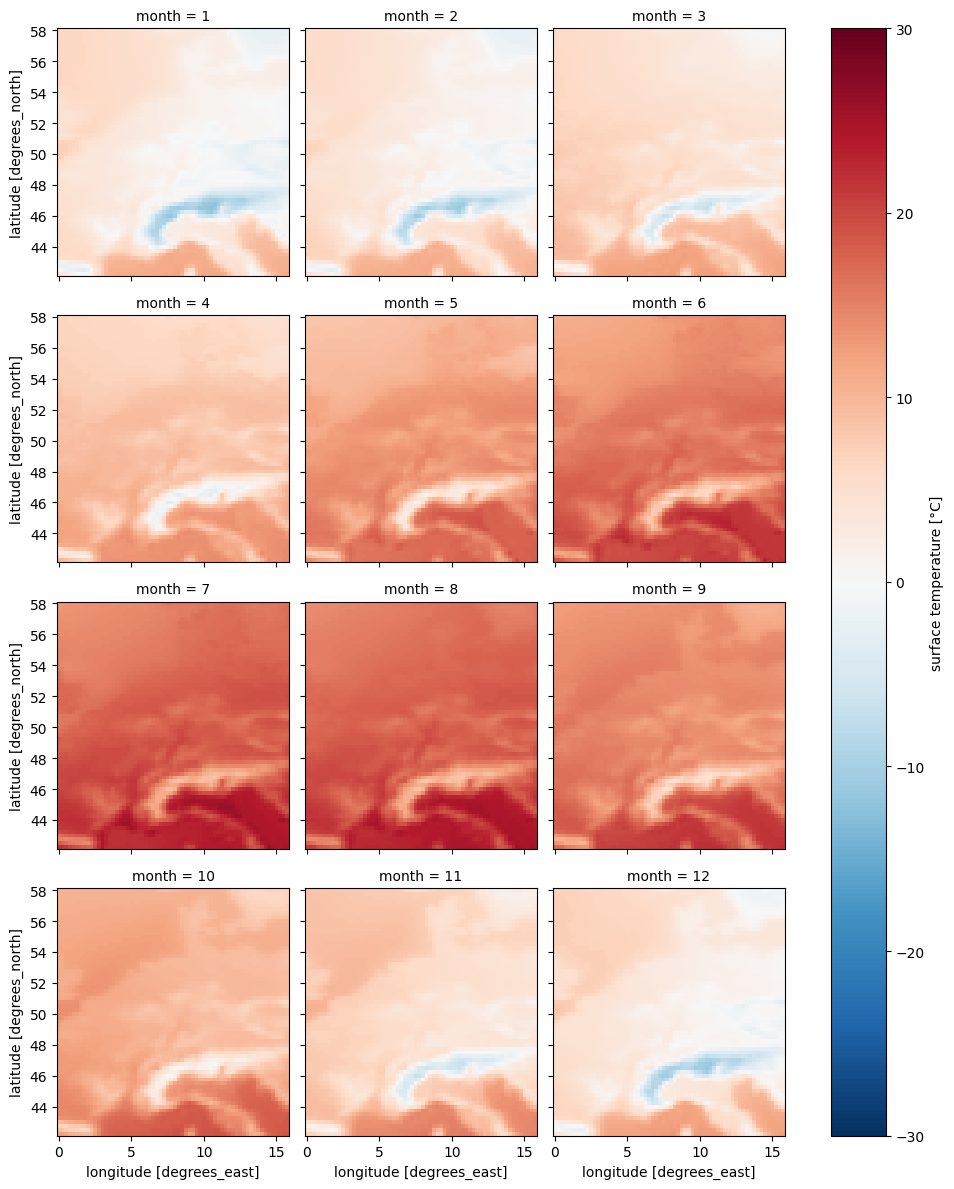

In [11]:
t2m_aoi_toi_month_mean.plot(vmin=-30, col="month", col_wrap=3)

#### Daily climatological mean and quintile extremes

In [12]:
%%time

t2m_aoi_toi_doy_mean = t2m_aoi_toi_data_C.groupby("valid_time.dayofyear").mean()
t2m_aoi_toi_doy_mean = t2m_aoi_toi_doy_mean.sel(dayofyear=slice(0, 365))
t2m_aoi_toi_doy_mean

CPU times: user 55 s, sys: 14.5 s, total: 1min 9s
Wall time: 1min 36s


<xarray.DataArray 't2m' (dayofyear: 365, latitude: 64, longitude: 64)> Size: 6MB
array([[[ 6.34202   ,  6.311117  ,  6.263548  , ..., -1.9055494 ,
         -1.9534662 , -1.8927022 ],
        [ 6.421534  ,  6.3819504 ,  6.3447976 , ..., -2.2319384 ,
         -2.0756884 , -1.9802022 ],
        [ 6.453131  ,  6.4194508 ,  6.379867  , ..., -1.9746467 ,
         -1.7739522 , -1.7722161 ],
        ...,
        [-1.2767301 , -1.4711745 , -1.5312439 , ..., 11.439937  ,
         11.506256  , 11.590284  ],
        [ 0.42604777, -0.36804944, -0.9190911 , ..., 11.496534  ,
         11.58195   , 11.641326  ],
        [ 3.5468812 ,  3.3156312 ,  2.89827   , ..., 11.462853  ,
         11.790978  , 11.80452   ]],

       [[ 6.4128532 ,  6.3680615 ,  6.332298  , ..., -2.6354105 ,
         -2.678466  , -2.5638828 ],
        [ 6.465978  ,  6.427437  ,  6.387159  , ..., -2.9942648 ,
         -2.8211744 , -2.6420078 ],
        [ 6.487506  ,  6.458687  ,  6.4229226 , ..., -2.7499938 ,
         -2.5260355 , -2.4232578 ],
...
        [-1.1315911 , -1.3183967 , -1.3399245 , ..., 11.547923  ,
         11.609381  , 11.664937  ],
        [ 0.5204922 , -0.20346612, -0.85416055, ..., 11.553478  ,
         11.646881  , 11.690631  ],
        [ 3.8861172 ,  3.5024366 ,  2.9649367 , ..., 11.4968815 ,
         11.8406315 , 11.841673  ]],

       [[ 6.557992  ,  6.512853  ,  6.4757004 , ..., -2.4572856 ,
         -2.526209  , -2.5171814 ],
        [ 6.5961866 ,  6.5555615 ,  6.5180616 , ..., -2.858501  ,
         -2.694612  , -2.6203065 ],
        [ 6.5864644 ,  6.557645  ,  6.529867  , ..., -2.6635356 ,
         -2.411973  , -2.3904452 ],
        ...,
        [-1.3973898 , -1.5786397 , -1.6322856 , ..., 11.61702   ,
         11.705909  , 11.800353  ],
        [ 0.44410333, -0.2795078 , -0.8760356 , ..., 11.686464  ,
         11.787853  , 11.859728  ],
        [ 3.7253532 ,  3.42327   ,  2.9340339 , ..., 11.712506  ,
         12.059034  , 12.0507    ]]], shape=(365, 64, 64), dtype=float32)
Coordinates:
  * dayofyear  (dayofyear) int64 3kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365
  * latitude   (latitude) float64 512B 58.0 57.75 57.5 ... 42.75 42.5 42.25
  * longitude  (longitude) float64 512B 0.0 0.25 0.5 0.75 ... 15.25 15.5 15.75
Attributes: (12/31)
    GRIB_NV:                                  0
    GRIB_Nx:                                  1440
    GRIB_Ny:                                  721
    GRIB_cfName:                              unknown
    GRIB_cfVarName:                           t2m
    GRIB_dataType:                            an
    ...                                       ...
    GRIB_typeOfLevel:                         surface
    GRIB_units:                               K
    GRIB_uvRelativeToGrid:                    0
    long_name:                                surface temperature
    standard_name:                            unknown
    units:                                    °C

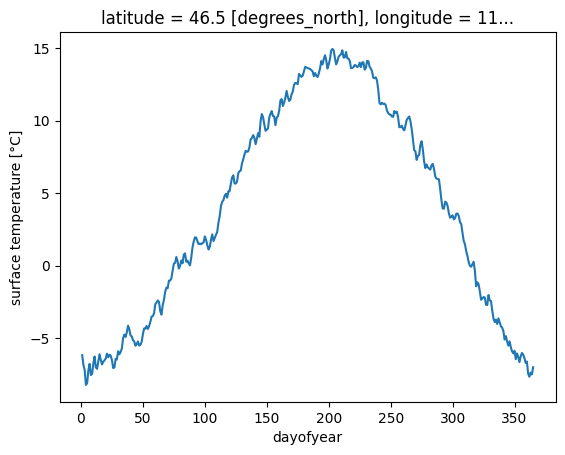

In [13]:
point = {
    "latitude": 46.5,
    "longitude": 11.8,
    "method": "nearest",
}

t2m_point_doy_mean = t2m_aoi_toi_doy_mean.sel(**point)

t2m_point_doy_mean.plot()

In [14]:
%%time

t2m_aoi_toi_doy_quantile = t2m_aoi_toi_data_C.groupby("valid_time.dayofyear").quantile(
    [0.9, 0.5, 0.1]
)
t2m_aoi_toi_doy_quantile = t2m_aoi_toi_doy_quantile.sel(dayofyear=slice(0, 365))
t2m_aoi_toi_doy_quantile

CPU times: user 2min 45s, sys: 10.4 s, total: 2min 55s
Wall time: 3min 51s


<xarray.DataArray 't2m' (dayofyear: 365, latitude: 64, longitude: 64,
                         quantile: 3)> Size: 36MB
array([[[[  8.3500061,   6.3500061,   4.1000061],
         [  8.3500061,   6.3500061,   3.8500061],
         [  8.6000061,   6.3500061,   3.8500061],
         ...,
         [  3.6000061,  -1.1499939,  -7.9249939],
         [  3.6000061,  -1.1499939,  -8.1499939],
         [  3.6250061,  -1.1499939,  -8.1499939]],

        [[  8.6000061,   6.6000061,   4.0750061],
         [  8.6000061,   6.3500061,   3.8500061],
         [  8.6000061,   6.3500061,   3.8500061],
         ...,
         [  3.3500061,  -1.3999939,  -8.8999939],
         [  3.3750061,  -1.3999939,  -8.6499939],
         [  3.6000061,  -1.3999939,  -8.6499939]],

        [[  8.6000061,   6.6000061,   4.1000061],
         [  8.6000061,   6.6000061,   3.8500061],
         [  8.6000061,   6.6000061,   3.8500061],
         ...,
...
         [ 14.6000061,  11.8500061,   8.3500061],
         [ 14.6000061,  12.1000061,   8.3500061],
         [ 14.8500061,  12.1000061,   8.5750061]],

        [[  4.6000061,   1.1000061,  -4.3999939],
         [  4.1000061,   0.3500061,  -5.9249939],
         [  3.3500061,  -0.1499939,  -6.6499939],
         ...,
         [ 14.6000061,  11.8500061,   8.6000061],
         [ 14.6250061,  11.8500061,   8.6000061],
         [ 14.8500061,  12.1000061,   8.8500061]],

        [[  8.8500061,   3.8500061,  -1.8999939],
         [  8.6000061,   3.3500061,  -2.1499939],
         [  8.1000061,   3.1000061,  -2.3999939],
         ...,
         [ 14.6000061,  11.8500061,   8.8500061],
         [ 15.1000061,  12.1000061,   9.1000061],
         [ 14.8500061,  12.3500061,   9.3500061]]]],
      shape=(365, 64, 64, 3))
Coordinates:
  * dayofyear  (dayofyear) int64 3kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365
  * latitude   (latitude) float64 512B 58.0 57.75 57.5 ... 42.75 42.5 42.25
  * longitude  (longitude) float64 512B 0.0 0.25 0.5 0.75 ... 15.25 15.5 15.75
  * quantile   (quantile) float64 24B 0.9 0.5 0.1
Attributes: (12/31)
    GRIB_NV:                                  0
    GRIB_Nx:                                  1440
    GRIB_Ny:                                  721
    GRIB_cfName:                              unknown
    GRIB_cfVarName:                           t2m
    GRIB_dataType:                            an
    ...                                       ...
    GRIB_typeOfLevel:                         surface
    GRIB_units:                               K
    GRIB_uvRelativeToGrid:                    0
    long_name:                                surface temperature
    standard_name:                            unknown
    units:                                    °C

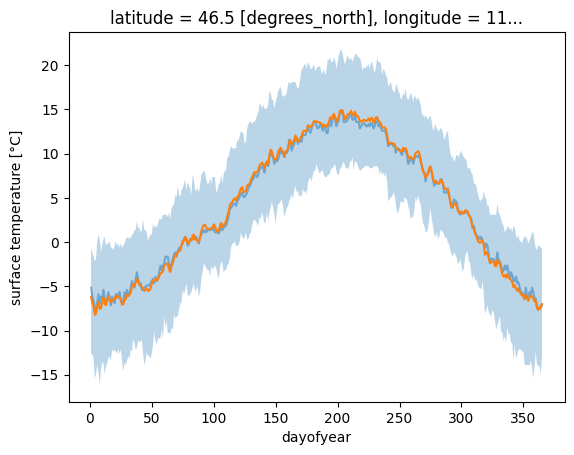

In [15]:
from matplotlib import pyplot as plt

_, ax = plt.subplots()

t2m_point_doy_quantile = t2m_aoi_toi_doy_quantile.sel(**point)

ax.fill_between(
    t2m_point_doy_quantile.dayofyear,
    t2m_point_doy_quantile.sel(quantile=0.9),
    t2m_point_doy_quantile.sel(quantile=0.1),
    alpha=0.3,
)

t2m_point_doy_quantile.sel(quantile=0.5).plot(ax=ax, alpha=0.5)
t2m_point_doy_mean.plot(ax=ax)